<div style="text-align:center;">
<h2 style="color:#2e86c1; font-family:Arial, sans-serif; font-size:24px; font-weight:bold;">
STEP 3.EXPLORATORY DATA ANALYSIS(EDA)
</h2>
</div>

                        
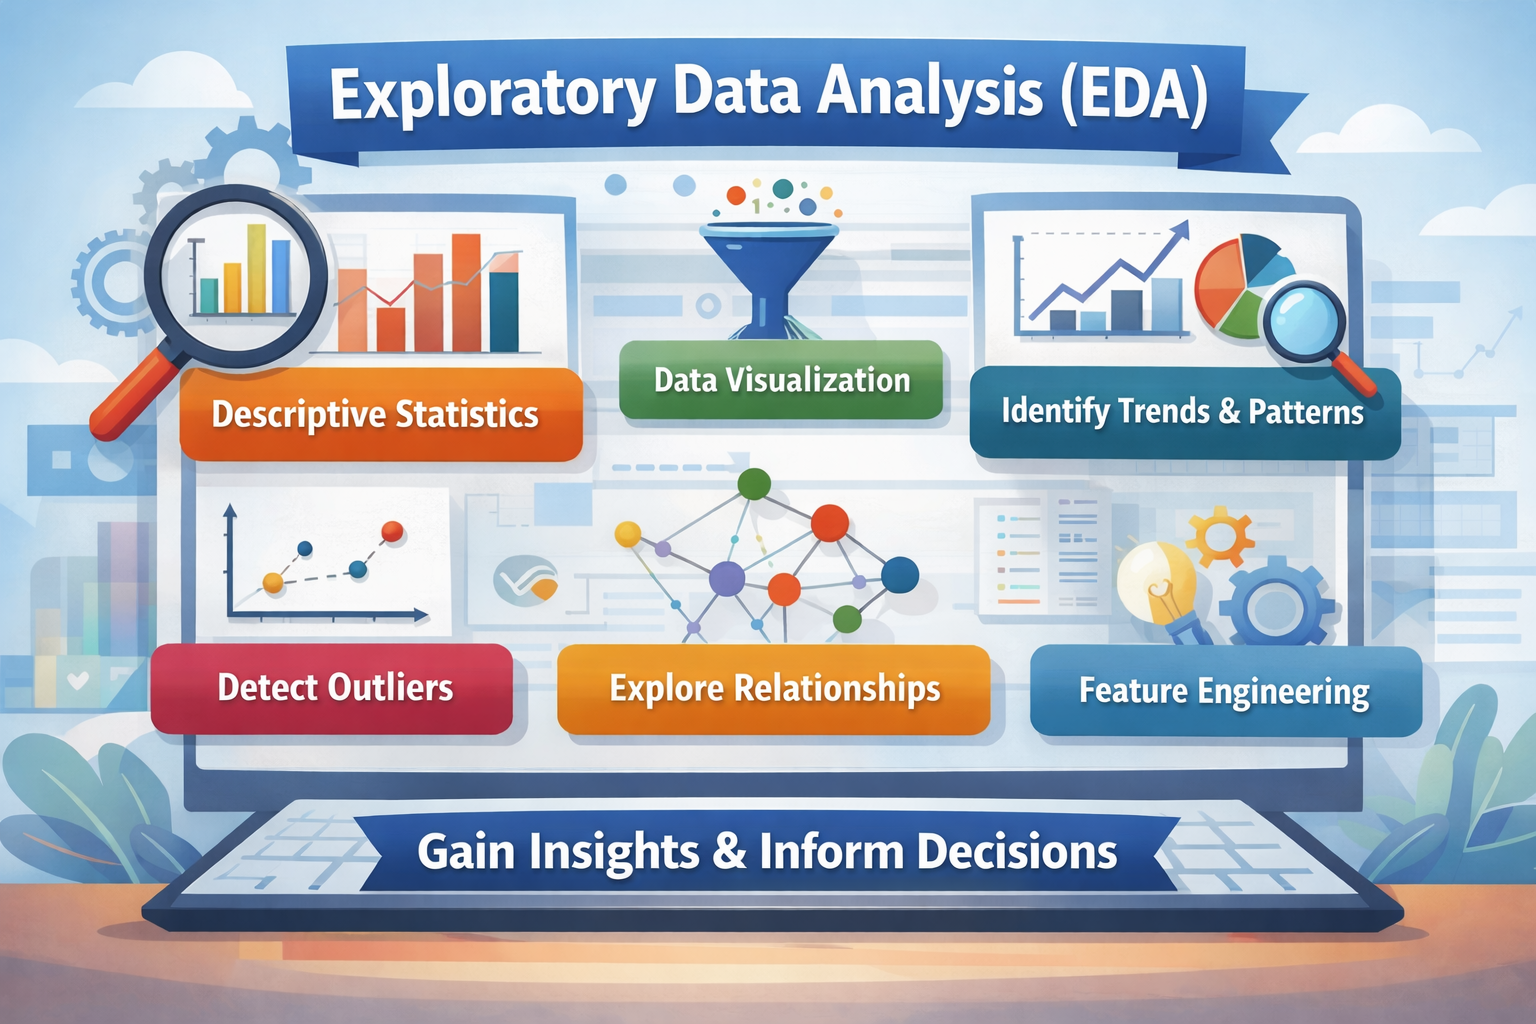

Exploratory Data Analysis (EDA) is performed to understand the dataset and identify important patterns, relationships, and trends. In this step, univariate, bivariate, and multivariate analysis are used to examine the distribution of individual variables and the relationships between multiple variables. Techniques such as groupby operations, pivot tables, and correlation analysis help summarize and compare data effectively. Statistical summaries are also used to provide key insights into the dataset and support the findings.

<div style="background-color:#e5e7eb; padding:8px; border-left:5px solid #2563eb; border-radius:5px;">
<h3 style="color:#1e3a8a; font-size:16px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
3.1 UNIVARIATE ANALYSIS
</h3>
</div>Univariate analysis focuses on analyzing one variable at a time to understand its distribution and basic properties in the dataset.

In [6]:
## VISITORS_COUNT

import pandas as pd
import numpy as np

df = pd.read_csv("tourism dataset.csv")

summary = df[['Visitors_Count']].describe()

summary


,Visitors_Count
count,11751.000000
mean,2501.133095
std,1437.364826
min,10.000000
25%,1260.000000
50%,2474.000000
75%,3749.000000
max,5000.000000


## Findings:

* The Visitors_Count column contains 11,751 records
* The average number of visitors is 2,501
* The visitor count ranges from 10 to 5,000
* The median value is 2,474,this indicates a moderate variation in tourist visits across              destinations

In [16]:
## DESTINATION_TYPE

destination_df = df['Destination_Type'].value_counts().reset_index()
destination_df.columns = ['Destination_Type','Count']

destination_df

,Destination_Type,Count
0,Adventure,2089
1,City Tourism,2055
2,Beach,1983
3,Hill Station,1965
4,Heritage,1962
5,Wildlife,1937


## Findings:

* The dataset includes different types of tourist destinations
* Adventure destinations have the highest count (2089)
* City Tourism (2055) and Beach destinations (1983) follow next
* Hill Station (1965) and Heritage (1962) have similar counts
* Wildlife destinations have the lowest count (1937)
* Overall, the dataset shows a balanced distribution of different tourism destination types

<div style="background-color:#e5e7eb; padding:10px; border-left:6px solid #2563eb; border-radius:6px;">
<h3 style="color:#1e3a8a; font-size:18px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
3.2 BIVARIATE ANALYSIS
</h3>
</div>Bivariate analysis examines the relationship between two variables to identify patterns, comparisons, and possible correlations within the dataset

In [17]:
##  SEASON VS VISITOR_TYPE

import pandas as pd

df = pd.read_csv("tourism dataset.csv")

season_visitor_df =pd.crosstab(df['Season'], df['Visitor_Type'])

season_visitor_df

Visitor_Type,Domestic,International
Season,,
Monsoon,1946,2008
Summer,2005,1962
Winter,2047,2026


## Findings:

* The number of domestic and international visitors is almost equal across all seasons
* Winter has the highest number of visitors
* Monsoon and Summer show similar visitor distributions


In [31]:
## SEASON VS DESTINATION_TYPE

season_destination_df = pd.DataFrame(pd.crosstab(df['Season'], df['Destination_Type']))

season_destination_df


Destination_Type,Adventure,Beach,City Tourism,Heritage,Hill Station,Wildlife
Season,,,,,,
Monsoon,664,652,688,695,635,619
Summer,703,662,684,607,658,650
Winter,720,668,682,660,672,667


## Findings:

* The distribution of destination types varies slightly across seasons
* Winter shows the highest number of destinations in most categories
* Adventure and Hill Station are especially higher in Winter
* Monsoon and Summer have relatively similar distributions
* Overall, seasonal variation is present but not very large

<div style="background-color:#e5e7eb; padding:10px; border-left:6px solid #2563eb; border-radius:6px;">
<h3 style="color:#1e3a8a; font-size:18px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
3.3 MULTIVARIATE ANALYSIS
</h3>
</div>Multivariate analysis is used to examine the relationship between more than two variables simultaneously in the dataset. It helps in identifying complex patterns and interactions among multiple

In [14]:
## SEASON,DESTINATION_TYPE,VISITORS_COUNT

import pandas as pd
import numpy as np
df = pd.read_csv("tourism dataset.csv")

df[['Season','Destination_Type','Visitors_Count']].head()





,Season,Destination_Type,Visitors_Count
0,Monsoon,Hill Station,214.0
1,Monsoon,Wildlife,254.0
2,Summer,City Tourism,3689.0
3,Winter,Wildlife,769.0
4,Winter,Hill Station,655.0


## Findings:

* The table shows the number of visitors based on season and destination type
* Winter shows moderate visitor numbers
* Monsoon has the lowest visitors, especially Hill Stations 
  

In [8]:
## SEASON ,DESTINATION_TYPE,AVERAGE_SPENDING
df = pd.read_csv("tourism dataset.csv")

df[['Season','Destination_Type','Average_Spending']].head()

,Season,Destination_Type,Average_Spending
0,Monsoon,Hill Station,227.634159
1,Monsoon,Wildlife,46.234685
2,Summer,City Tourism,184.994391
3,Winter,Wildlife,126.379649
4,Winter,Hill Station,174.571374


## Findings:

* Average spending varies across seasons and destination types
* Higher spending is observed in Hill Stations and City Tourism
* Wildlife destinations generally show lower spending
* Seasonal differences influence tourist spending patterns

<div style="background-color:#e5e7eb; padding:10px; border-left:6px solid #2563eb; border-radius:6px;">
<h3 style="color:#1e3a8a; font-size:18px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
3.4 GROUPBY ANALYSIS
</h3>
</div>GroupBy is a technique in Pandas used to split data into groups based on one or more columns and then apply aggregation functions (like sum, mean, count) to each group.

In [21]:
## DESTINATION_TYPE BY VISITORS_COUNT

import pandas as pd
df = pd.read_csv("tourism dataset.csv")

result = df.groupby('Destination_Type')['Visitors_Count'].mean().reset_index().round()
print(result)


  Destination_Type  Visitors_Count
0        Adventure          2527.0
1            Beach          2511.0
2     City Tourism          2512.0
3         Heritage          2457.0
4     Hill Station          2500.0
5         Wildlife          2497.0


## Findings:

* The average number of visitors is quite similar across all destination types
* Adventure has the highest average visitors (2527)
* Beach (2511) and City Tourism (2512) attract nearly equal visitors
* Hill Station and Wildlife have slightly lower but comparable averages
* Heritage has the lowest average (2457)

In [22]:
## TOTAL VISITORS BY SEASON

season_total = df.groupby('Season', as_index=False)['Visitors_Count'].sum().round(0)
print(season_total)

    Season  Visitors_Count
0  Monsoon       9664307.0
1   Summer       9733683.0
2   Winter       9978958.0


## Findings:

* Tourism is highest during Winter, making it the most preferred season for travel
* Summer also attracts a large number of visitors
* Monsoon has comparatively fewer visitors, possibly due to weather conditions
* Tourism peaks in Winter and remains strong in Summer
* There is a slight decline in tourism during the Monsoon season

<div style="background-color:#e5e7eb; padding:10px; border-left:6px solid #2563eb; border-radius:6px;">
<h3 style="color:#1e3a8a; font-size:18px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
3.5 PIVOT TABLE
</h3>
</div>A Pivot Table is a powerful feature in Pandas used to summarize, reorganize, and analyze data by multiple categories in a table format.

In [1]:
import pandas as pd

df = pd.read_csv("tourism dataset.csv")
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

# 1. Total Visitors by Season and Visitor Type
pivot1 = df.pivot_table(values='Visitors_Count',index='Season',columns='Visitor_Type', aggfunc='sum')

# 2.Average Spending by Visitor Type and Destination
pivot2 = df.pivot_table(values='Average_Spending',index='Visitor_Type',columns='Destination_Type',aggfunc='mean')

# 3. Total Visitors and Average Spending by Season
pivot3 = df.pivot_table(values=['Visitors_Count', 'Average_Spending'],index='Season',aggfunc={'Visitors_Count': 'sum', 'Average_Spending': 'mean'})

print("\n 1. Total Visitors by Season and Visitor Type:\n", pivot1)
print("\n 2. Average Spending by Visitor Type and Destination:\n", pivot2)
print("\n 3. Visitors & Spending by Season:\n", pivot3)

Columns: ['Visit_ID', 'Tourist_Origin', 'Destination _City', 'Destination_Type', 'Visitor_Type', 'Season', 'Visit_Date', 'Visitors_Count', 'Average_Rating', 'Revenue_USD', 'Average_Spending']

 1. Total Visitors by Season and Visitor Type:
 Visitor_Type   Domestic  International
Season                                
Monsoon       4783375.0      4880932.0
Summer        4900750.0      4832933.0
Winter        5080782.0      4895712.0

 2. Average Spending by Visitor Type and Destination:
 Destination_Type   Adventure       Beach  City Tourism    Heritage  \
Visitor_Type                                                         
Domestic          156.115734  158.455645    159.655639  155.819715   
International     155.974872  159.646532    152.192154  155.403541   

Destination_Type  Hill Station    Wildlife  
Visitor_Type                                
Domestic            153.850179  157.615905  
International       155.622095  156.918276  

 3. Visitors & Spending by Season:
          A

## Findings:

* Winter is the peak season with the highest visitors and spending
* Summer and Monsoon follow with comparatively lower tourism activity
* Domestic and international tourists are evenly distributed
* Spending remains fairly consistent across visitor types and destinations
* Only slight variations are observed in spending patterns
* Overall tourism performance is mainly driven by season and visitor count rather than spending differences

<div style="background-color:#e5e7eb; padding:10px; border-left:6px solid #2563eb; border-radius:6px;">
<h3 style="color:#1e3a8a; font-size:18px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
3.6 CORRELATION ANALYSIS
</h3>
</div>Correlation analysis is a technique used to measure the relationship between two numerical variables. It tells us how strongly and in what direction the variables are related.

Correlation Matrix:

                  Visitors_Count  Average_Rating  Revenue_USD  \
Visitors_Count          1.000000       -0.003755     0.700425   
Average_Rating         -0.003755        1.000000     0.001288   
Revenue_USD             0.700425        0.001288     1.000000   
Average_Spending        0.008498       -0.001905     0.596415   

                  Average_Spending  
Visitors_Count            0.008498  
Average_Rating           -0.001905  
Revenue_USD               0.596415  
Average_Spending          1.000000  


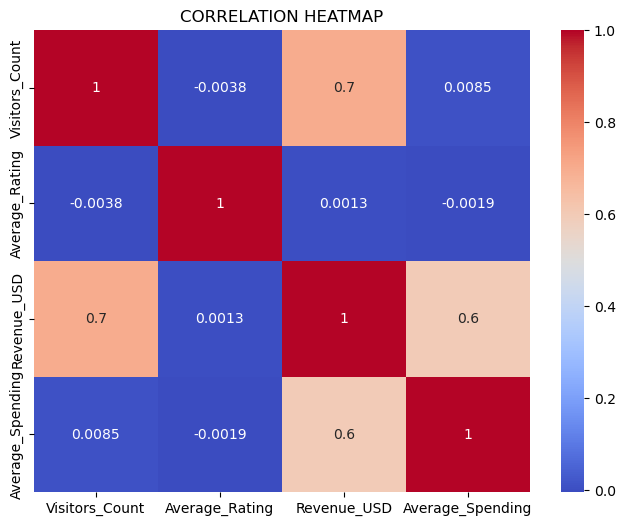

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("tourism dataset.csv")

# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation matrix
correlation = numeric_df.corr()

#  DataFrame
print("Correlation Matrix:\n")
print(correlation)

#  Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("CORRELATION HEATMAP")
plt.show()

## Findings:

* Visitors_Count and Revenue_USD have a strong positive correlation (0.70)
* Higher visitor numbers lead to increased revenue
* Revenue_USD and Average_Spending show a moderate positive correlation (0.59)
* Higher spending contributes to higher revenue
* Average_Rating has almost no correlation with other variables
* Ratings do not significantly impact visitors, revenue, or spending
* Overall, revenue is mainly influenced by visitor count and spending behavior

<div style="background-color:#e5e7eb; padding:10px; border-left:6px solid #2563eb; border-radius:6px;">
<h3 style="color:#1e3a8a; font-size:18px; font-weight:bold; font-family:Arial, sans-serif; margin:0;">
3.7 STATISTICAL SUMMARY
</h3>
</div>Statistical summaries to support findings means using numerical measures such as mean, median, minimum, maximum, and standard deviation to clearly describe and validate the patterns observed in the data. Instead of relying only on visual interpretation or assumptions, these statistics provide concrete evidence about how the data is distributed and how variables behave.This approach makes the analysis more reliable, objective, and data-driven, ensuring that conclusions are supported by measurable insights rather than just observations.

In [4]:
import pandas as pd

df = pd.read_csv("tourism dataset.csv")

# Select relevant columns
multi_df = df[['Season','Destination_Type','Average_Spending']]

# Overall statistical summary
print("\nOverall Summary:\n")
print(multi_df['Average_Spending'].describe())

# Statistical summary by Season
print("\nSummary by Season:\n")
print(multi_df.groupby('Season')['Average_Spending'].describe())

# Statistical summary by Destination Type
print("\nSummary by Destination Type:\n")
print(multi_df.groupby('Destination_Type')['Average_Spending'].describe())


Overall Summary:

count    12000.000000
mean       156.409350
std         83.499859
min          0.000000
25%         84.357109
50%        156.349074
75%        228.588421
max        299.987173
Name: Average_Spending, dtype: float64

Summary by Season:

          count        mean        std  min        25%         50%  \
Season                                                               
Monsoon  3954.0  154.904493  83.782941  0.0  81.998199  154.113392   
Summer   3967.0  157.102913  83.303638  0.0  86.084399  156.493997   
Winter   4074.0  157.155733  83.346464  0.0  84.453565  158.567621   

                75%         max  
Season                           
Monsoon  227.503671  299.984283  
Summer   229.801632  299.934360  
Winter   228.522125  299.987173  

Summary by Destination Type:

                   count        mean        std  min        25%         50%  \
Destination_Type                                                              
Adventure         2089.0  156.04466

## Findings:

* The overall average spending is around 156, with a wide spread (std ≈ 83), indicating high variability in tourist    spending
* Spending ranges from 0 to ~300, showing the presence of both very low and high spenders
* The median (≈156) is close to the mean, suggesting a fairly symmetric distribution
* Across seasons, Winter and Summer have slightly higher average spending than Monsoon
* However, spending patterns are very similar across all seasons, indicating minimal seasonal impact on spending
* Across destination types, average spending is fairly consistent (around 154–159)
* Beach destinations show slightly higher average spending, while Hill Stations are slightly lower
* The variation (std ≈ 83) is similar across all destination types, showing consistent spending behavior
* Overall, tourist spending is stable across seasons and destinations, with only minor variations
* This suggests that spending behavior is relatively uniform, regardless of season or destination type


<div style="background-color:#eff6ff; padding:12px; border-left:6px solid #3b82f6; border-radius:6px;">
<h2 style="color:#1e3a8a; font-size:20px; margin:0; font-weight:bold;">
EXPLORATORY DATA ANALYSIS SUMMARY
</h2>
</div>

 
* Exploratory Data Analysis (EDA) was conducted to identify patterns and trends in the dataset
* Univariate, bivariate, and multivariate analyses were performed for deeper insights
* GroupBy operations and pivot tables were used to summarize and compare data
* Correlation analysis was applied to understand relationships between variables
* Statistical summaries were included to support and validate the findings
* Overall, EDA helped in understanding data distribution, trends, and key influencing factors